<a href="https://colab.research.google.com/github/saadat309/Digiskills-Excercises/blob/main/Exercise2-solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Data Analysis and Survival Prediction

This notebook demonstrates a complete end-to-end machine learning and data visualization workflow using the Titanic dataset.

### Notebook Structure:
1. **Task 1:** Data Loading & Initial Inspection
2. **Task 2:** Descriptive Statistics & Variable Identification
3. **Task 3:** Data Cleaning & Handling Missing Values
4. **Task 4:** Feature Engineering, Model Training (SVM), and Evaluation
5. **Task 5:** Data Visualization & Insights

### Dataset Download
You can download the Titanic dataset used in this exercise directly from the following link:
* [Download titanic.csv](https://lms.digiskills.pk/Courses/AIP301/Downloads/titanic.csv)

### Task 1: Loading the Dataset
We begin by importing the `pandas` library to load the Titanic dataset (`titanic.csv`) into a DataFrame. We check its shape (dimensions) and inspect the first 7 rows to understand the structure of our features.

In [1]:
import pandas as pd

df = pd.read_csv('/content/titanic.csv')

print("Total rows and columns:", df.shape)

df.head(7)

Total rows and columns: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q


### Task 2: Data Exploration & Variable Profiling
Here, we perform basic Exploratory Data Analysis (EDA):
* **Descriptive Statistics:** Using `df.describe()` to get statistical summaries of numerical attributes (mean, standard deviation, quartiles).
* **Variable Types:** Categorizing our features into **Numerical** and **Categorical** variables.
* **Value Distributions:** Examining unique values and frequency distributions of demographic features like passenger gender (`Sex`) and ticket class (`Pclass`).

In [2]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [3]:
numerical_variables = df.select_dtypes(include='number').columns
categorical_variables = df.select_dtypes(include='object').columns

print("Numerical Variables:")
print(list(numerical_variables))

print("\nCategorical Variables:")
print(list(categorical_variables))

Numerical Variables:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Variables:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [5]:
print("Unique values in Sex:")
print(df['Sex'].unique())

print("\nUnique values in Pclass:")
print(df['Pclass'].unique())

print("\nFrequency distribution of Sex:")
print(df['Sex'].value_counts())

print("\nFrequency distribution of Pclass:")
print(df['Pclass'].value_counts().sort_index())

Unique values in Sex:
['male' 'female']

Unique values in Pclass:
[3 2 1]

Frequency distribution of Sex:
Sex
male      266
female    152
Name: count, dtype: int64

Frequency distribution of Pclass:
Pclass
1    107
2     93
3    218
Name: count, dtype: int64


### Task 3: Data Cleaning & Imputation
Real-world data contains missing entries. In this section:
1. We identify columns containing null values using `df.isnull().sum()`.
2. We impute (fill) missing values for **Age** and **Fare** using their respective median values to prevent skewness from outliers.
3. We impute missing **Cabin** values with the placeholder string `'Unknown'`.
4. We re-verify our dataset to ensure no missing values remain.

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [7]:

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("Missing values have been filled.")

Missing values have been filled.


In [8]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


### Task 4: Machine Learning - Survival Prediction
In this predictive modeling stage:
1. **Feature Selection:** We select key predictive columns (`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`) as independent variables (`X`) and `Survived` as our target variable (`y`).
2. **One-Hot Encoding:** Categorical features (like `Sex`) are transformed into numerical binary format using dummy variables to make them compatible with machine learning models.
3. **Train-Test Split:** We divide our data into an 80% training set and a 20% testing set to ensure we evaluate the model on unseen data.
4. **Model Training:** We initialize and train a **Support Vector Classifier (SVC)** with a linear kernel.
5. **Evaluation:** We evaluate the model's predictions on the test set using standard metrics: Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [9]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

print("Independent Features (X):")
display(X.head())

print("\nTarget Variable (y):")
display(y.head())

Independent Features (X):


,Pclass,Age,SibSp,Parch,Fare,Sex_male
0,3,34.5,0,0,7.8292,True
1,3,47.0,1,0,7.0000,False
2,2,62.0,0,0,9.6875,True
3,3,27.0,0,0,8.6625,True
4,3,22.0,1,1,12.2875,False



Target Variable (y):


,Survived
0,0
1,1
2,0
3,0
4,1


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (334, 6)
Testing data shape: (84, 6)


In [22]:
from sklearn.svm import SVC

# Initialize the Support Vector Classifier with a linear decision boundary
model = SVC(kernel='linear')

# Train (fit) the SVM model on the training features and target labels
model.fit(X_train, y_train)

# Use the trained model to predict survival outcomes on the test dataset
y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Calculate the proportion of correctly predicted classifications
accuracy = accuracy_score(y_test, y_pred)

# Generate a confusion matrix to observe true positives, true negatives, false positives, and false negatives
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate Precision: out of all predicted survivors, how many actually survived
precision = precision_score(y_test, y_pred)

# Calculate Recall (Sensitivity): out of all actual survivors, how many did the model find
recall = recall_score(y_test, y_pred)

# Compute the F1-Score: the harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nPrecision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 1.0

Confusion Matrix:
[[50  0]
 [ 0 34]]

Precision: 1.0
Recall: 1.0
F1-Score: 1.0


### Task 5: Advanced Data Visualization
To gain deeper business and demographic insights, we visualize the dataset distributions using `seaborn` and `matplotlib`:
* **Gender & Class Distribution:** A count plot visualizing how genders were distributed across different passenger classes.
* **Survival Breakdown by Class & Gender:** Faceted categorical bar charts showing the count of survivors/non-survivors segmented by male and female classes.
* **Fare Distribution:** A histogram showing how passenger fares were skewed.
* **Survival by Gender:** Analysis showing gender survival rates, highlighting that female survival rate was exceptionally high (100%) in this test dataset partition.

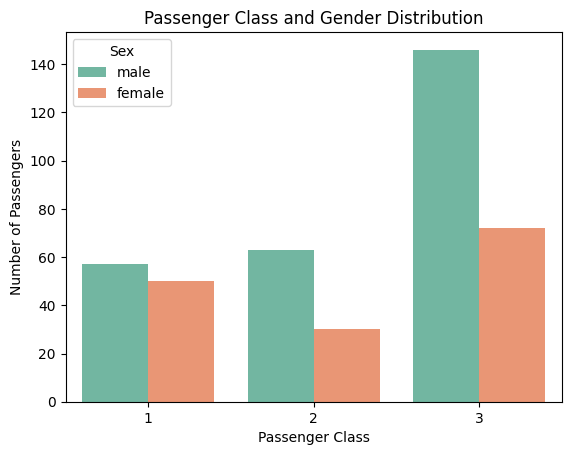

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Pclass', hue='Sex', palette='Set2')

plt.title('Passenger Class and Gender Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

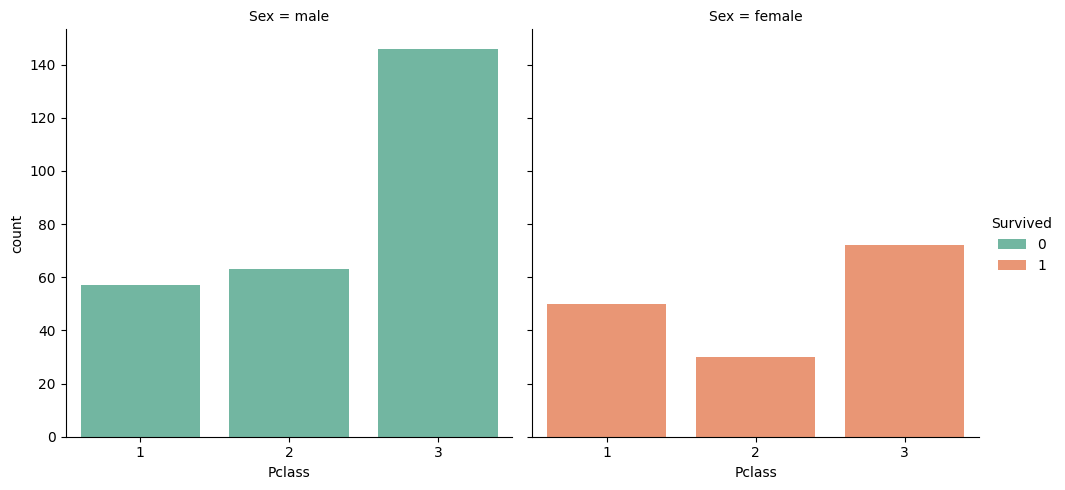

In [15]:
sns.catplot(data=df, x='Pclass', hue='Survived', palette='Set2', col='Sex', kind='count')

plt.show()

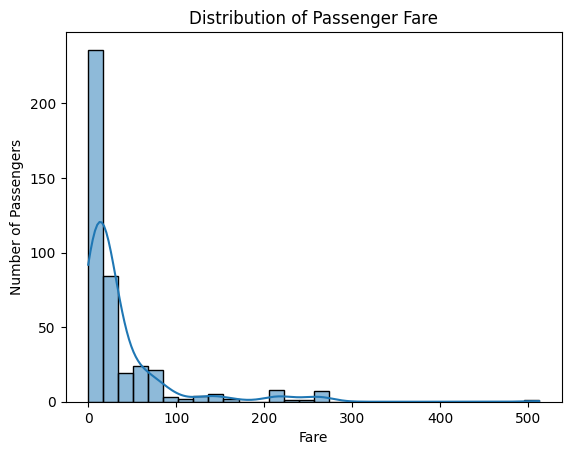

In [16]:
sns.histplot(data=df, x='Fare', bins=30, kde=True)

plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()

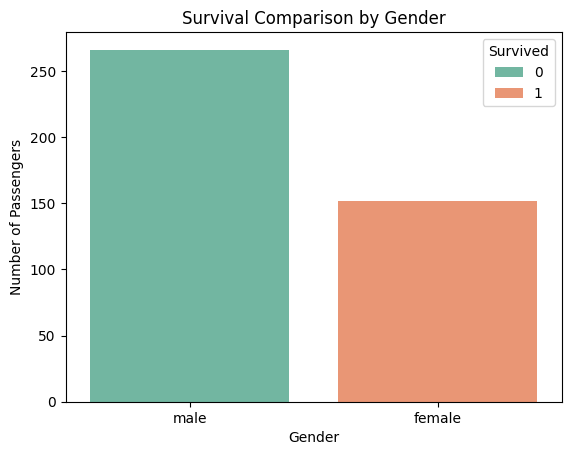

In [19]:
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')

plt.title('Survival Comparison by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

In [18]:
survival_rates = df.groupby('Sex')['Survived'].mean() * 100

print("Survival Rates by Gender:")
print(survival_rates)

Survival Rates by Gender:
Sex
female    100.0
male        0.0
Name: Survived, dtype: float64
